In [130]:
from scipy import signal as sig
import numpy as np
import matplotlib.pyplot as plt 
import scipy.io as sio
from scipy.io.wavfile import write
from numbers import Integral
from numbers import Real

%matplotlib widget


# CONSIGNA

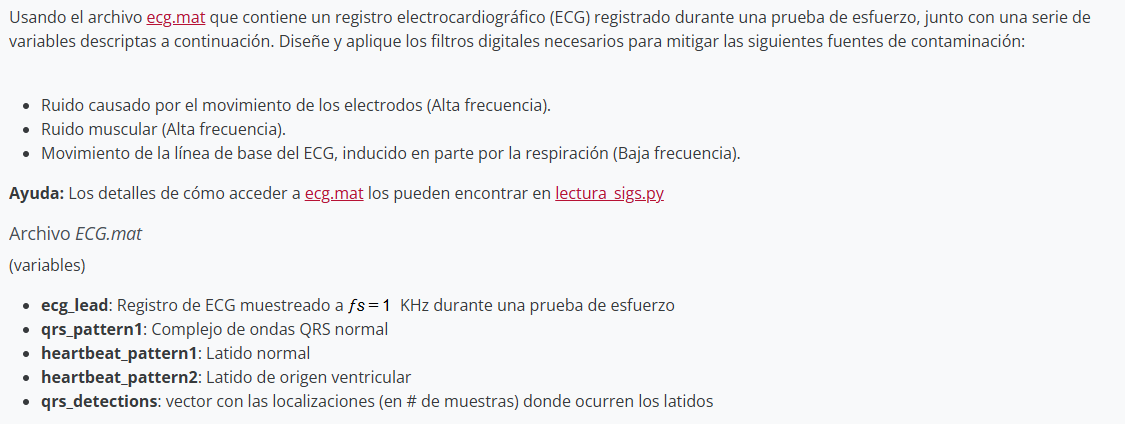
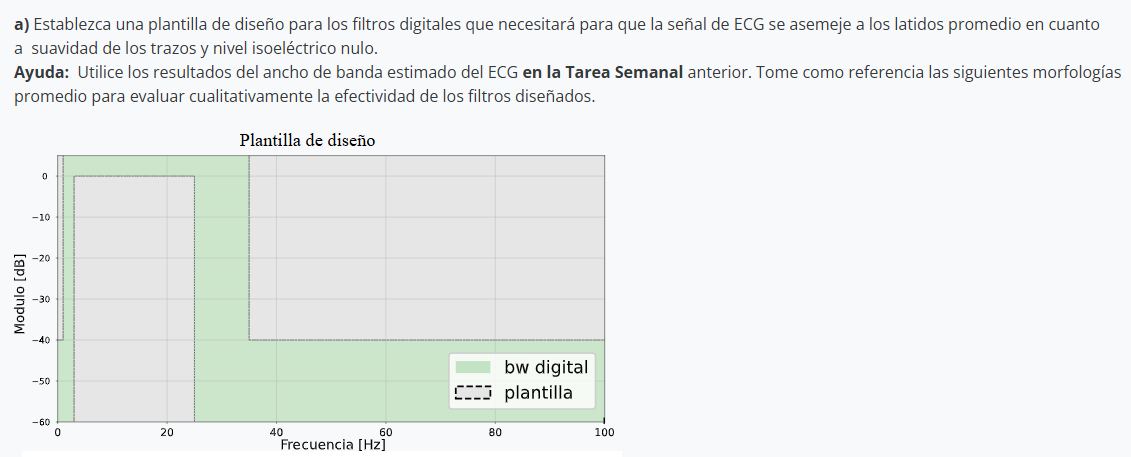
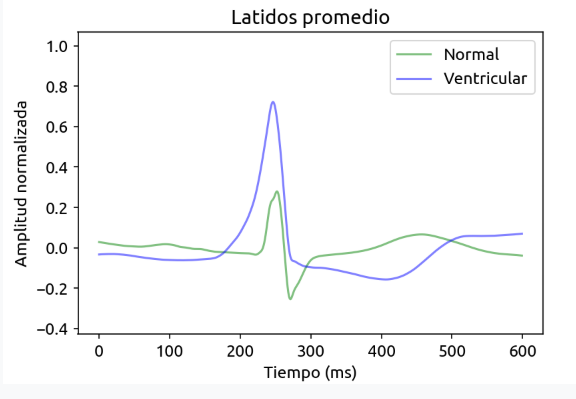
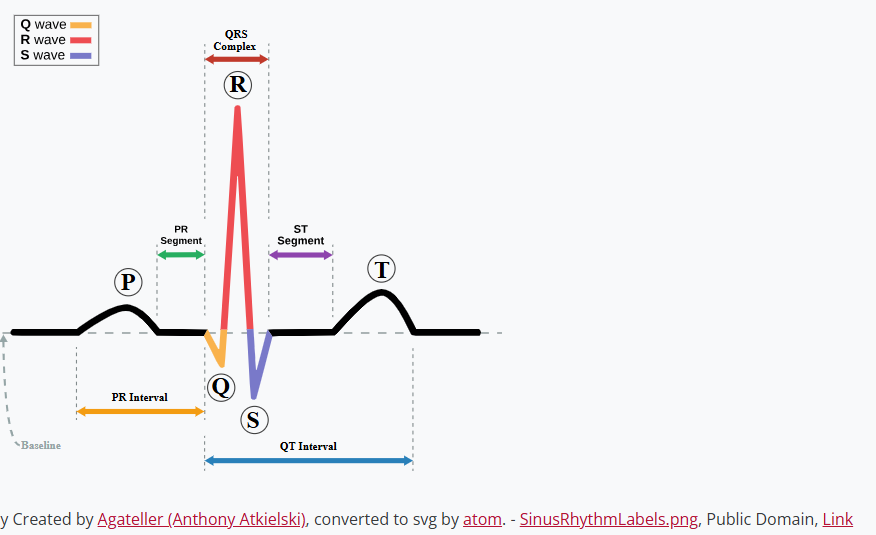
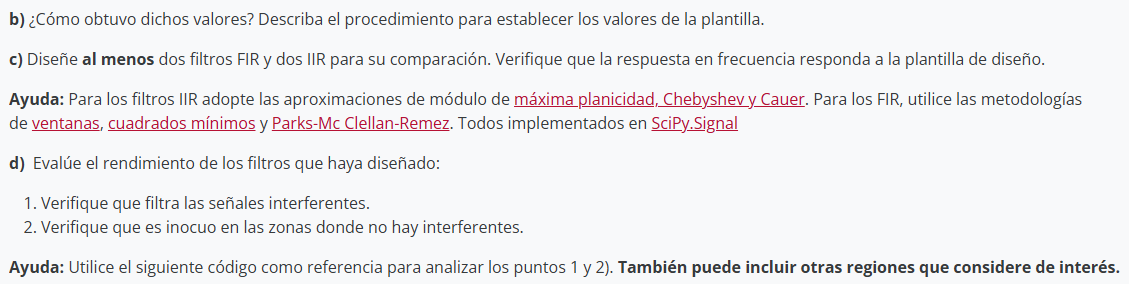

# Funciones

In [131]:
def plot_pzmap(z, p, *args, **kwargs):
    fig, ax = plt.subplots(*args, **kwargs)
    plt.scatter(np.real(z), np.imag(z), color='b', marker='o')
    plt.scatter(np.real(p), np.imag(p), color='r', marker='x')
    circle = plt.Circle((0,0), 1, fill=False)
    ax.add_patch(circle)
    ax.set_xlim((-1.1, 1.1))
    ax.set_ylim((-1.1, 1.1))

    ax.axhline(0, color='black')
    ax.axvline(0, color='black')
    plt.grid(True, which='both', ls='--')
    plt.title('Polos y Ceros del Filtro')
    plt.ylabel('Real')
    plt.xlabel('Imaginario')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    return fig, ax

def plot_filt_mag(w, H, title='Filtro', ax=None, label=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10,8))

    mag = 20*np.log10(np.maximum(np.abs(H), 1e-13))
    ax.plot(w, mag, label=label)
    ax.set_title(f'{title} - Respuesta en amplitud')
    ax.set_ylabel('Magnitud [dB]')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.grid(True, which='both', ls='--')

    if label is not None:
        ax.legend()

    return ax


def plot_filt_phase(w, H, title='Filtro', ax=None, label=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10,8))

    phase = np.unwrap(np.angle(H))
    ax.plot(w, phase, label=label)
    ax.set_title(f'{title} - Respuesta en fase')
    ax.set_ylabel('Fase [rad]')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.grid(True, which='both', ls='--')

    if label is not None:
        ax.legend()

    return ax


def plot_filt_delay(f, H, title='Filtro', ax=None, label=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10,8))

    phase = np.unwrap(np.angle(H))
    gd = -np.diff(phase)/(2*np.pi*np.diff(f))
    gd = np.append(gd, gd[-1])

    ax.plot(f, gd, label=label)
    ax.set_title(f'{title} - Retardo de grupo')
    ax.set_ylabel('Retardo [s]')
    ax.set_xlabel('Frecuencia [Hz]')
    ax.grid(True, which='both', ls='--')

    if label is not None:
        ax.legend()

    return ax

def plot_filt_resp(w, H, title='Filtro', ax=None, label=None):
    if ax is None:
        _, ax = plt.subplots(3, 1, figsize=(10,8))

    plot_filt_mag(w, H, title, ax[0], label)
    plot_filt_phase(w, H, title, ax[1], label)
    plot_filt_delay(w, H, title, ax[2], label)

    return ax


def plot_plantilla(filter_type='', fpass=0.25, ripple=0.5, fstop=0.6, attenuation=40, fs=2):
    """
    Plotea una plantilla de diseño de filtro digital.

    Parameters
    -----------
    filter_type : str, opcional
        Tipo de filtro ('lowpass', 'highpass', 'bandpass', 'bandstop'). Por defecto es 'lowpass'.
    fpass : float o tupla, opcional
        Frecuencia de paso o tupla de frecuencias de paso para los filtros 'bandpass' o 'bandstop'.
    ripple : float, opcional
        Máxima ondulación en la banda de paso (en dB). Por defecto es 0.5 dB.
    fstop : float o tupla, opcional
        Frecuencia de detención o tupla de frecuencias de detención para los filtros 'bandpass' o 'bandstop'.
    attenuation : float, opcional
        Atenuación mínima en la banda de detención (en dB). Por defecto es 40 dB.
    fs : float, opcional
        Frecuencia de muestreo. Por defecto es 2.
        
    Returns
    --------
    None


    Raises
    ------
    ValueError
        Si los argumentos no son del tipo o valor correcto.
    

    See Also
    -----------
    :func:`analyze_sys`

    
    Example
    --------
    >>> # Analiza un sistema con w0 = 1 rad/s y Q = sqrt(2)/2
    >>> import numpy as np
    >>> from scipy import signal as sig
    >>> import matplotlib.pyplot as plt
    >>> from pytc2.sistemas_lineales import bodePlot, plot_plantilla
    >>> Q = np.sqrt(2)/2
    >>> w0 = 1
    >>> num = np.array([w0**2])
    >>> den = np.array([1., w0 / Q, w0**2])
    >>> H1 = sig.TransferFunction(num, den)
    >>> fig_id, axes_hdl = bodePlot(H1, fig_id=1, axes_hdl='none', filter_description='Filtro pasa bajos', worN=1000, digital=False, xaxis='omega', fs=2*np.pi)
    >>> plt.sca(axes_hdl[0])
    >>> plot_plantilla(filter_type='lowpass', fpass=1.0, ripple=3, fstop=3.0, attenuation=20, fs=2)

    """

    if not isinstance(fpass, (tuple, np.ndarray, Integral, Real)):
        raise ValueError("fpass debe ser un float o una tupla de frecuencias de paso.")
    
    if not isinstance(fstop, (tuple, np.ndarray, Integral, Real)):
        raise ValueError("fstop debe ser un float o una tupla de frecuencias de detención.")
    
    if not isinstance(attenuation, (tuple, np.ndarray, Integral, Real)):
        try:
            attenuation = np.float64(attenuation)
        except ValueError:
            raise ValueError("attenuation debe ser un valor numérico o convertible a float.")    
    
    if not isinstance(ripple, (tuple, np.ndarray, Integral, Real)):
        try:
            ripple = np.float64(ripple)
        except ValueError:
            raise ValueError("attenuation debe ser un valor numérico o convertible a float.")    
    
    if not isinstance(fs, (Integral, Real)):
        try:
            fs = np.float64(fs)
        except ValueError:
            raise ValueError("fs debe ser un valor numérico o convertible a float.")    

    # Obtener los límites actuales de los ejes
    xmin, xmax, ymin, ymax = plt.axis()

    # Banda de paso digital
    plt.fill([xmin, xmin, fs / 2, fs / 2], [ymin, ymax, ymax, ymin], 'lightgreen', alpha=0.2, lw=1, label='Banda de paso digital')

    # analizar los valores de la plantilla para ver qué tipo de plantilla es
    tipos_permitidos = ['lowpass', 'highpass', 'bandpass', 'bandstop']
    if filter_type not in tipos_permitidos:
            
        if isinstance(fpass, (tuple, np.ndarray)) and isinstance(fstop, (tuple, np.ndarray)):
            if fstop[0] < fpass[0]:
                filter_type = 'bandpass'
            else:                
                filter_type = 'bandstop'
        else:
            if fstop < fpass:
                filter_type = 'highpass'
            else:                
                filter_type = 'lowpass'

    if filter_type == 'lowpass':
        # Definir regiones de banda de detención y banda de paso para el filtro pasa bajos
        fstop_start = fstop
        fstop_end = xmax
        fpass_start = xmin
        fpass_end = fpass
    elif filter_type == 'highpass':
        # Definir regiones de banda de detención y banda de paso para el filtro pasa altos
        fstop_start = xmin
        fstop_end = fstop
        fpass_start = fpass
        fpass_end = xmax
    elif filter_type == 'bandpass':
        if len(fpass) == 2 and len(fstop) == 2:
            fstop_start = xmin
            fstop_end = fstop[0]
            fpass_start = fpass[0]
            fpass_end = fpass[1]
            fstop2_start = fstop[1]
            fstop2_end = xmax
        else:
            raise ValueError("En modo bandpass, fpass y fstop deben ser tuplas con 2 valores.")
    elif filter_type == 'bandstop':
        if len(fpass) == 2 and len(fstop) == 2:
            fpass_start = xmin
            fpass_end = fpass[0]
            fstop_start = fstop[0]
            fstop_end = fstop[1]
            fpass2_start = fpass[1]
            fpass2_end = xmax
        else:
            raise ValueError("En modo bandstop, fpass y fstop deben ser tuplas con 2 valores.")
    else:
        raise ValueError("filtro_type debe ser 'lowpass', 'highpass', 'bandpass', o 'bandstop'.")

    # Plotea regiones de banda de detención y banda de paso
    plt.fill([fstop_start, fstop_end, fstop_end, fstop_start], [-attenuation, -attenuation, ymax, ymax], 'lightgrey', alpha=0.4, hatch='x', lw=1, ls='--', ec='k')
    plt.fill([fpass_start, fpass_start, fpass_end, fpass_end], [ymin, -ripple, -ripple, ymin], 'lightgrey', alpha=0.4, hatch='x', lw=1, ls='--', ec='k', label='Plantilla')
    
    # Plotea región adicional de banda de detención para filtro pasa banda
    if filter_type == 'bandpass':
        plt.fill([fstop2_start, fstop2_end, fstop2_end, fstop2_start], [-attenuation, -attenuation, ymax, ymax], 'lightgrey', alpha=0.4, hatch='x', lw=1, ls='--', ec='k')
    
    # Plotea región adicional de banda de paso para filtro rechaza banda
    if filter_type == 'bandstop':
        plt.fill([fpass2_start, fpass2_start, fpass2_end, fpass2_end], [ymin, -ripple, -ripple, ymin], 'lightgrey', alpha=0.4, hatch='x', lw=1, ls='--', ec='k')
    
    # Establece los límites de los ejes
    plt.axis([xmin, xmax, np.max([ymin, -100]), np.max([ymax, 1])])


# Señal

Señal de ECG con una frecuencia de muestreo de 1KHz tomada de un alumno. Presenta 2 zonas específicas denominadas heartbeat_pattern1 y heartbeat_pattern2

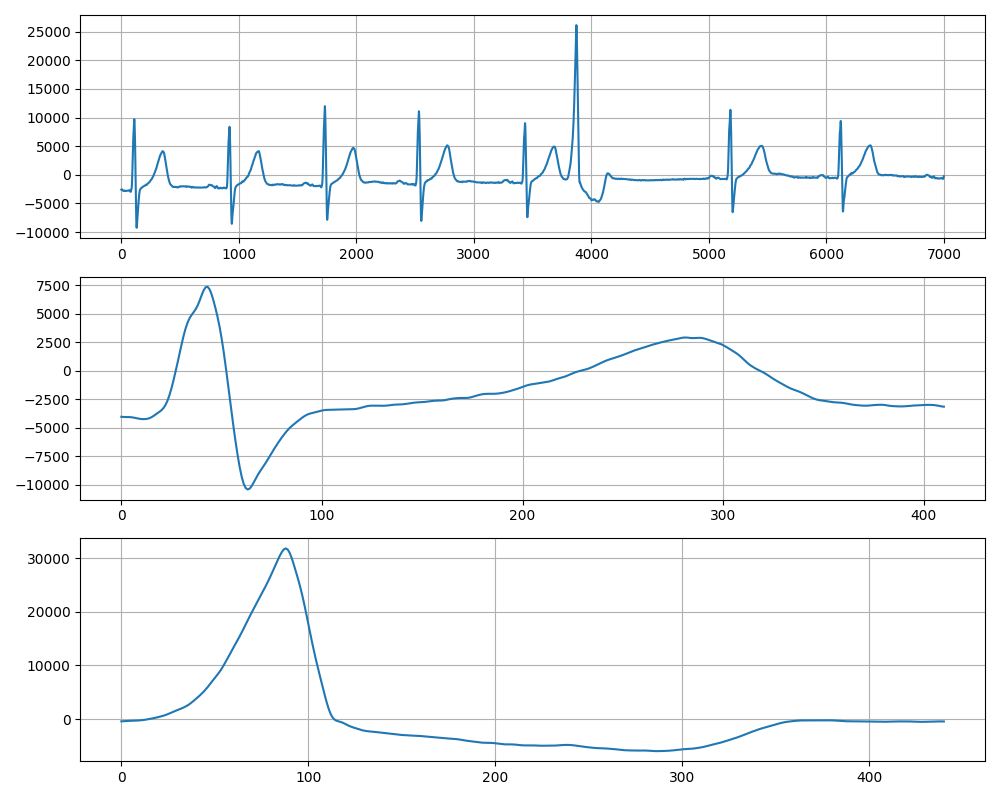

In [132]:
# Lectura de ECG #
fs = 1000 # Hz

# para listar las variables que hay en el archivo
#sio.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten()
cant_muestras = len(ecg_one_lead)

hb_1 = mat_struct['heartbeat_pattern1'].flatten()
hb_2 = mat_struct['heartbeat_pattern2'].flatten()

plt.figure(figsize=(10,8))
plt.subplot(3,1,1)
plt.plot(ecg_one_lead[5000:12000])
plt.grid()

plt.subplot(3,1,2)
plt.plot(hb_1)
plt.grid()

plt.subplot(3,1,3)
plt.plot(hb_2)
plt.grid()

plt.tight_layout()
plt.show()


# Filtro IIR a realizar

Se realiza un filtro pasabanda con frecuencias de paso comprendidas entre 1Hz y 35Hz. Se rechazan frecuencias menores a .1Hz y mayores a 50Hz.
Estas frecuencias, según investigado, corresponden al rango útil de un ecg mientras que lo demás se puede considerar ruido por los electrodos, muscular, de respiración, etc.

El filtro a realizar es IIR

In [133]:
N = fs                # Cant Muestras
f0 = [1, 35]         # Freq de paso
f_cutoff = [.1, 50]    # Freq de stop

Att_pass_db = 1         # ATT en banda de paso. Tambien se conoce como ripple.
att_stop_db = 40        # ATT en banda de stop

sos_butt = sig.iirdesign(wp=f0, ws=f_cutoff, 
                       gpass=Att_pass_db, gstop=att_stop_db, fs=fs, 
                       analog=False, ftype='butter', output='sos')

sos_cauer = sig.iirdesign(wp=f0, ws=f_cutoff, 
                       gpass=Att_pass_db, gstop=att_stop_db, fs=fs, 
                       analog=False, ftype='cauer', output='sos')

sos_cheby1 = sig.iirdesign(wp=f0, ws=f_cutoff,    
                           gpass=Att_pass_db, gstop=att_stop_db, fs=fs,
                           analog=False, ftype='cheby1', output='sos')

print("Butter order:", sos_butt.shape[0]*2)
print("Cauer order:", sos_cauer.shape[0]*2)
print("Cheby order:", sos_cheby1.shape[0]*2)

Butter order: 30
Cauer order: 10
Cheby order: 14


# Gráficos de Filtro 
 Solo de Cauer

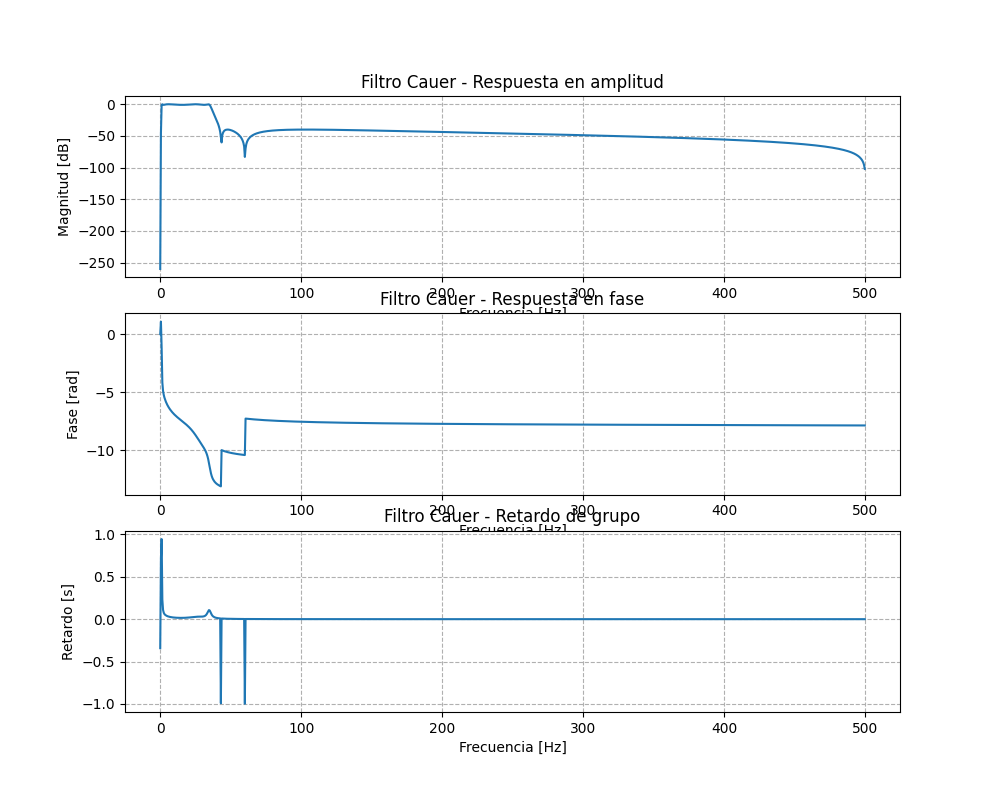

In [134]:
#w = np.concatenate( [np.logspace(-2, stop = np.log10(2), num = 250),
#					 np.linspace(2.1, stop = 34, num = 250),
#					 np.logspace(np.log10(34.5), stop = np.log10(2), num = 250),
#					 np.linspace(2.1, stop = 34, num = 250)])

f, H = sig.freqz_sos(sos_cauer, worN=N,  fs=fs)
# WorN: Omega o N. Le pasás el valor de mayor detalle para realizar el analisis del filtro.
plot_filt_resp(f, H, title='Filtro Cauer')
plt.show()

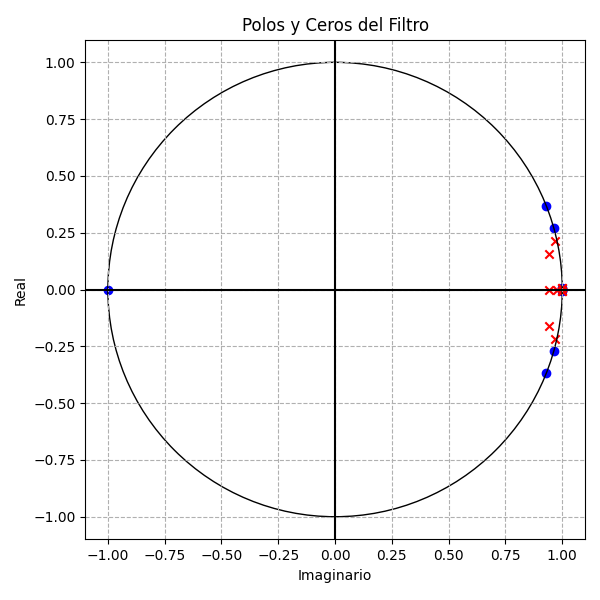

In [135]:
z, p, k = sig.sos2zpk(sos_cauer)

plot_pzmap(z,p, figsize=(6,6))
plt.show()

# Implementación de los Filtros en Regiones de interés

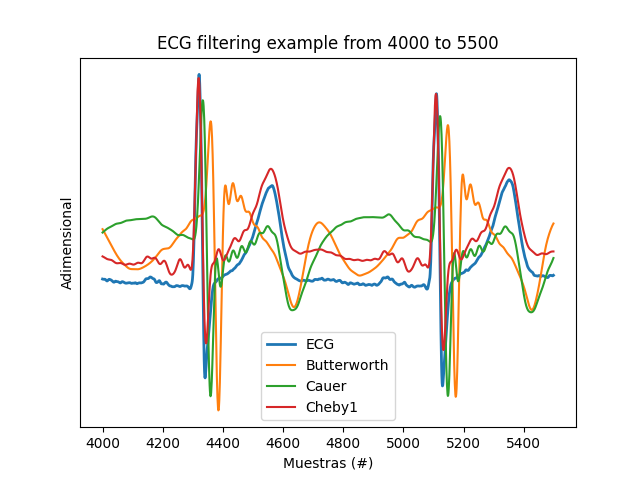

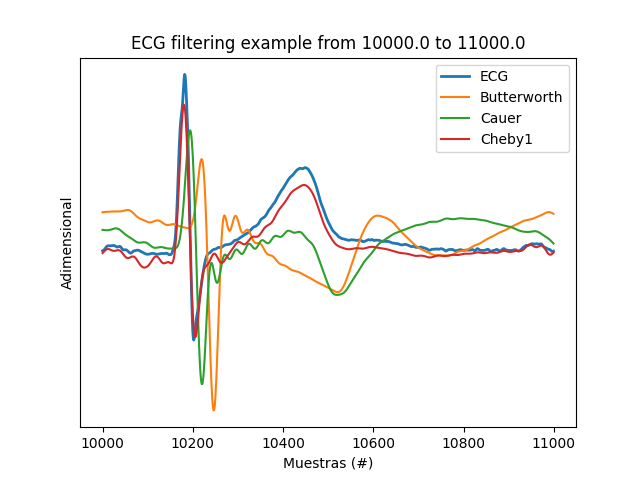

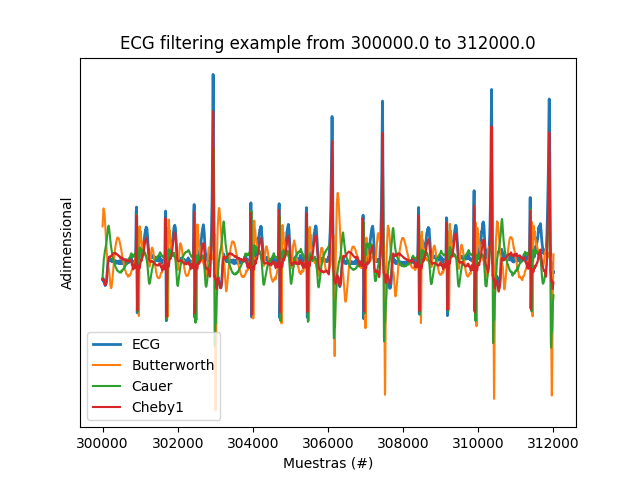

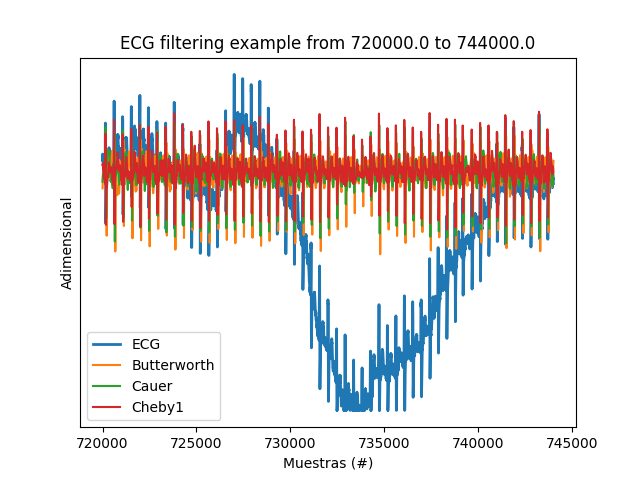

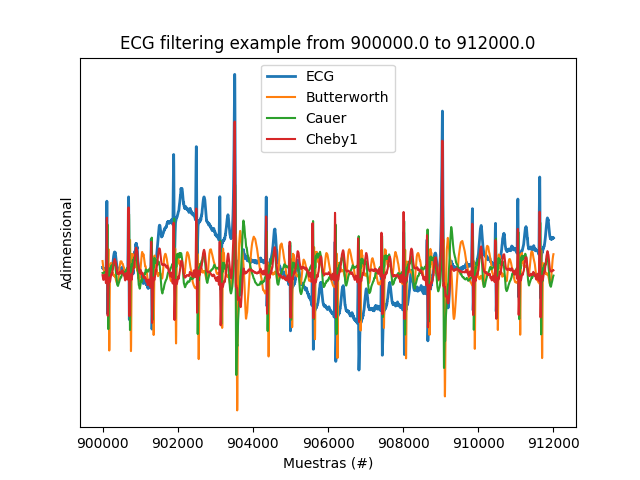

In [136]:
ECG_f_butt = sig.sosfilt(sos_butt, ecg_one_lead)    #ZI: Condiciones iniciales para el filtro.
ECG_f_cauer = sig.sosfilt(sos_cauer, ecg_one_lead) 
ECG_f_cheby1 = sig.sosfiltfilt(sos_cheby1, ecg_one_lead)

#%% Regiones de interés con ruido 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby1[zoom_region], label='Cheby1')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
#%% Regiones de interés sin ruido 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby1[zoom_region], label='Cheby1')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

# Forward Backward filter


Utilizando la propiedad de espejado temporal
x(-t) --> X*(w)
Se puede obtener el complejo conjugado a la salida del filtro. 
Si el resultado del filtrado lo vuelvo a espejar y lo vuelvo a pasar por el filtro, se obtendría:

X --> X* --> FILTRO(T) --> X* T --> ESPEJO --> (X* T)* --> FILTRO(T) --> X T* T 

El resultado es X T* T. Eso es igual a X |T|^2
Se observa que la fase de T ya no tiene efecto en el filtrado, solo su módulo.

Se logra sos.sosfiltfilt

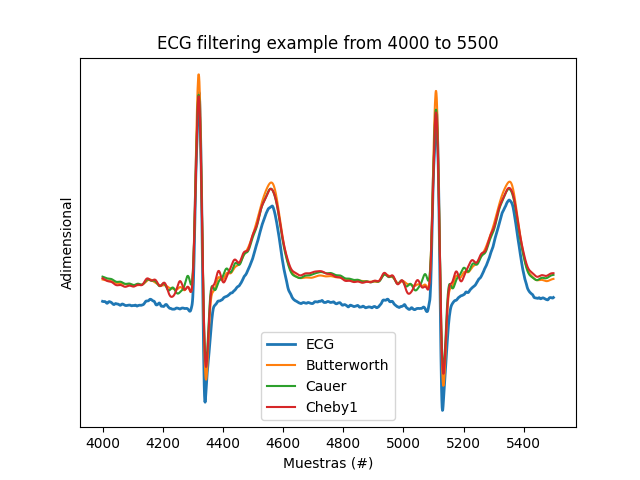

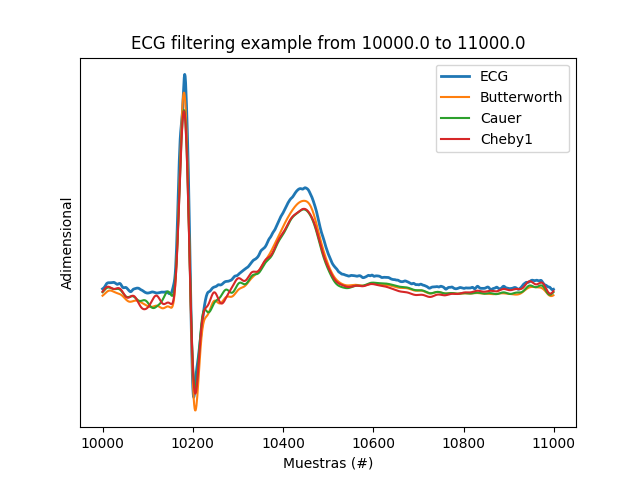

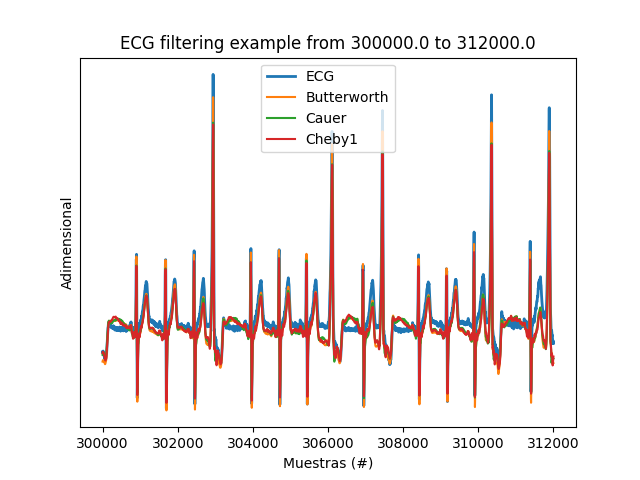

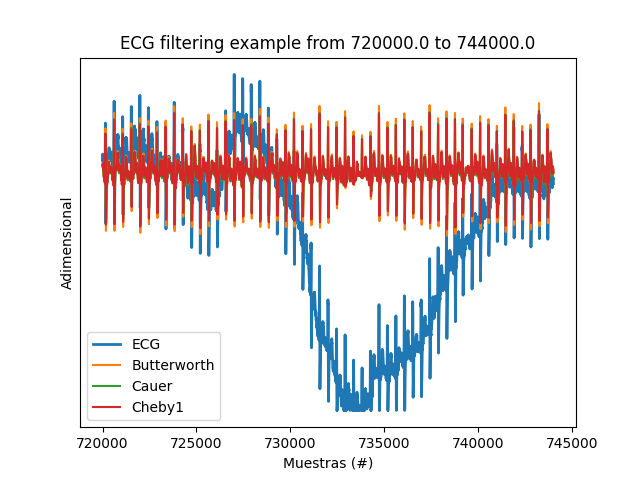

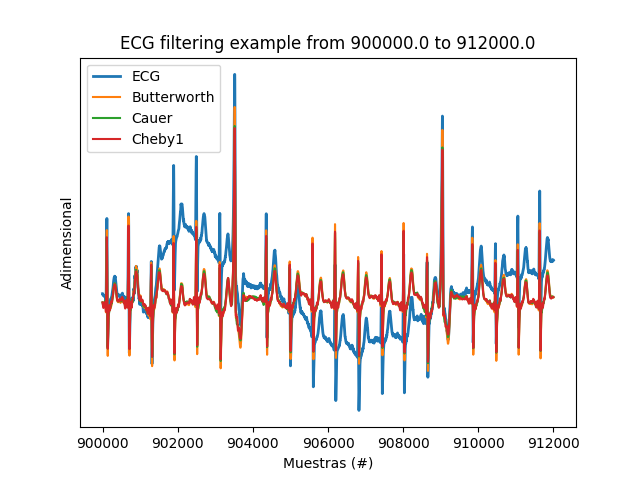

In [137]:
ECG_f_butt = sig.sosfiltfilt(sos_butt, ecg_one_lead)    #ZI: Condiciones iniciales para el filtro.
ECG_f_cauer = sig.sosfiltfilt(sos_cauer, ecg_one_lead) 
ECG_f_cheby1 = sig.sosfiltfilt(sos_cheby1, ecg_one_lead)

#%% Regiones de interés con ruido # 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby1[zoom_region], label='Cheby1')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
#%% Regiones de interés sin ruido #
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_cauer[zoom_region], label='Cauer')
    plt.plot(zoom_region, ECG_f_cheby1[zoom_region], label='Cheby1')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

# Filtro FIR

## Método de ventana

El método de ventana es el más sencillo de todos. Este se configura eligiendo el número de taps y ajustando las frecuencias. Además, se debe elegir la mejor ventana para nuestro caso. Se llega a la conclusión, al realizar 3 pruebas, que la ventana boxcar es la más adecuada para este caso. El filtro final tendrá taps impares y será antisimétrico. Esto nos coloca un cero en continua y en fs/2, ambas condiciones que nos convienen para esta plantilla.

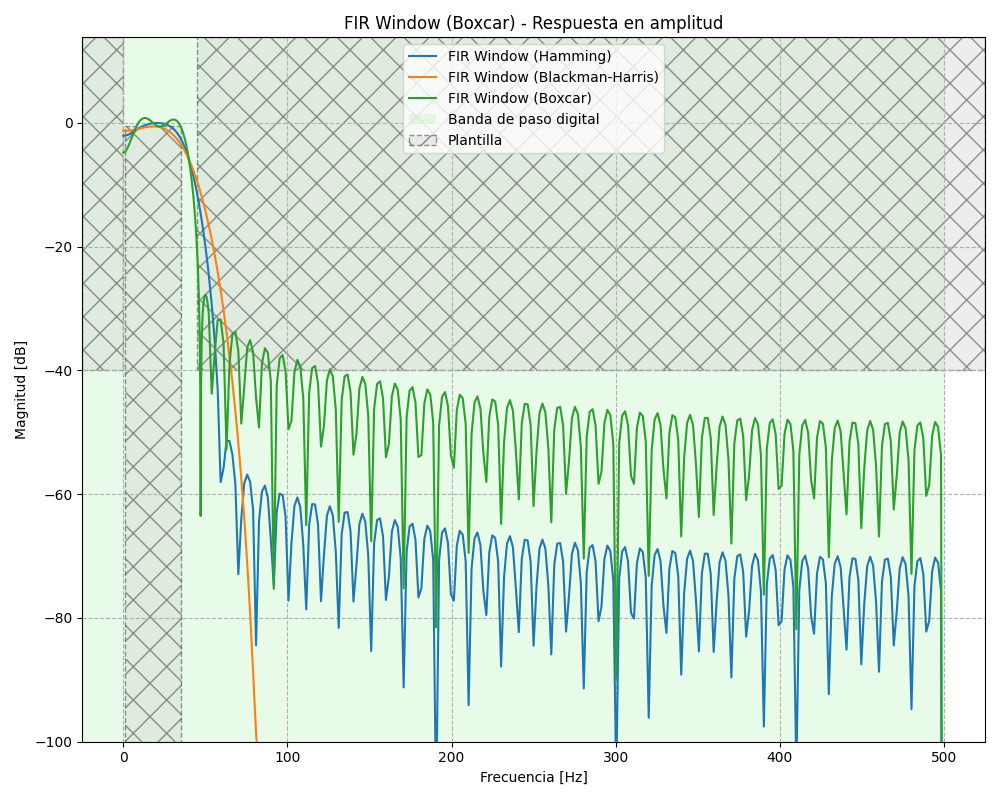

In [138]:
freqs = [0, 0.1, 0.5, 35, 45, 500]
# gain = [0, 40, 0.5, 0.5, 40, 0]
gain = [0, 0, 1, 1, 0, 0]
Ntaps = 100
fs = 1000 # Hz
N = 5000
ww = np.concatenate( [ np.logspace(start = -2, stop = np.log10(2), num = 250 ),
                       np.linspace(start = 2.1, stop = 34, num = 250 ),
                       np.logspace(start = np.log10(34.1), stop = np.log10(52), num = 250 ),
                       np.linspace(start = 52.1, stop = fs/2, num = 250 )] )

num_win_methd = sig.firwin2(Ntaps, freqs, gain, fs=fs, window='hamming')
f, h_win = sig.freqz(b=num_win_methd, a=[1], worN=ww, fs=fs)

num_win2_methd = sig.firwin2(Ntaps, freqs, gain, fs=fs, window='blackmanharris')
f, h_win2 = sig.freqz(b=num_win2_methd, a=[1], worN=ww, fs=fs)

num_win3_methd = sig.firwin2(Ntaps, freqs, gain, fs=fs, window='boxcar')
f, h_win3 = sig.freqz(b=num_win3_methd, a=[1], worN=ww, fs=fs)

plt.clf()
ax = plot_filt_mag(f, h_win, 'FIR Window (Hamming)', ax=None, label='FIR Window (Hamming)')
ax = plot_filt_mag(f, h_win2, 'FIR Window (Blackman-Harris)',ax=ax, label='FIR Window (Blackman-Harris)')
ax = plot_filt_mag(f, h_win3, 'FIR Window (Boxcar)', ax=ax, label='FIR Window (Boxcar)')
plt.legend()

fpass = (1.0, 35.0)
fstop = (0.1, 45.0)
att_pass = 0.5
att_stop = 40
plot_plantilla(filter_type='bandpass', fpass=fpass, ripple=att_pass, fstop=fstop, attenuation=att_stop, fs=fs)

plt.legend()
plt.tight_layout()
plt.show()


Se observa que la ventana boxcar es la que permite la transición abrupta de la mejor forma

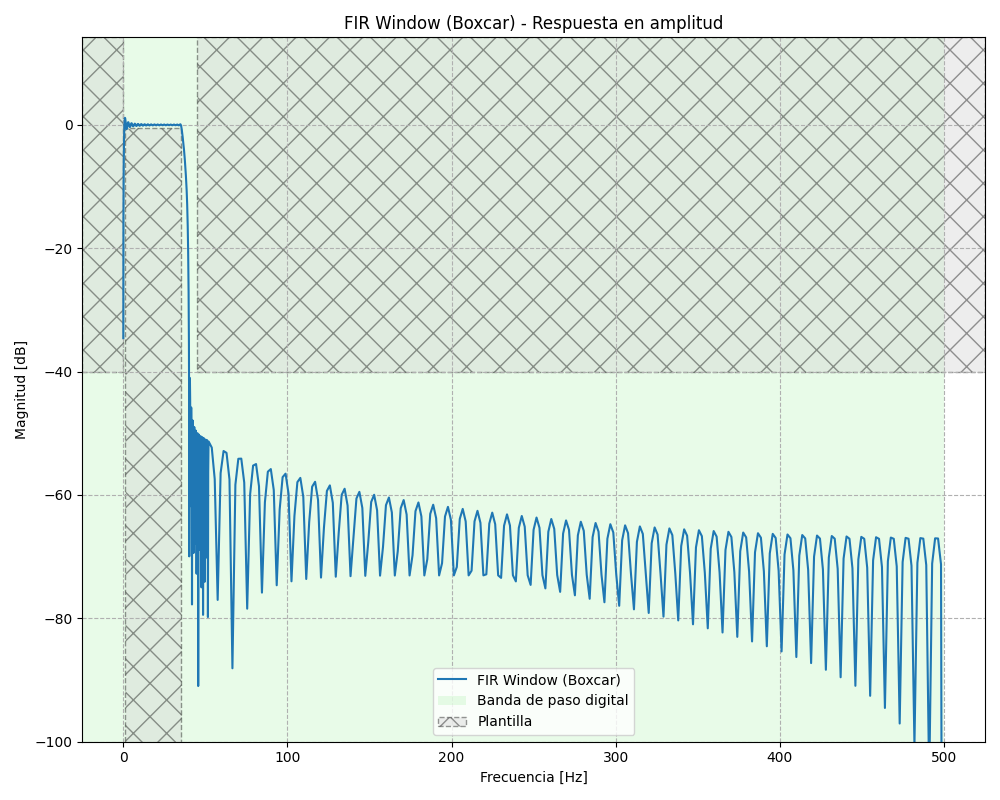

In [139]:
inc_f = 0.15
freqs = [0, 0.1 + .1, 0.5 - .2, 35 + .2, 45 - 5, 500]
# gain = [0, 40, 0.5, 0.5, 40, 0]
gain = [0, 0, 1, 1, 0, 0]
Ntaps_win = 1001
fs = 1000 # Hz
N = 10000
ww = np.concatenate( [ np.logspace(start = -2, stop = np.log10(2), num = 250 ),
                       np.linspace(start = 2.1, stop = 34, num = 250 ),
                       np.logspace(start = np.log10(34.1), stop = np.log10(52), num = 250 ),
                       np.linspace(start = 52.1, stop = fs/2, num = 250 )] )

num_win_methd = sig.firwin2(Ntaps_win, freqs, gain, fs=fs, window='boxcar', antisymmetric=True)
f, h_win = sig.freqz(b=num_win_methd, a=[1], worN=ww, fs=fs)

#plt.clf()
ax = plot_filt_mag(f, h_win, 'FIR Window (Boxcar)', ax=None, label='FIR Window (Boxcar)')
plt.legend()

fpass = (1.0, 35.0)
fstop = (0.1, 45.0)
att_pass = 0.5
att_stop = 40
plot_plantilla(filter_type='bandpass', fpass=fpass, ripple=att_pass, fstop=fstop, attenuation=att_stop, fs=fs)

plt.legend()
plt.tight_layout()
plt.show()


## Método de cuadrados mínimos

Este método intenta minimizar el error entre la plantilla ideal y real. Para que mejore el resultado se aumenta la cantidad de taps y se ajustan las frecuencias para definir un filtro más estricto al real a la hora de diseñar.

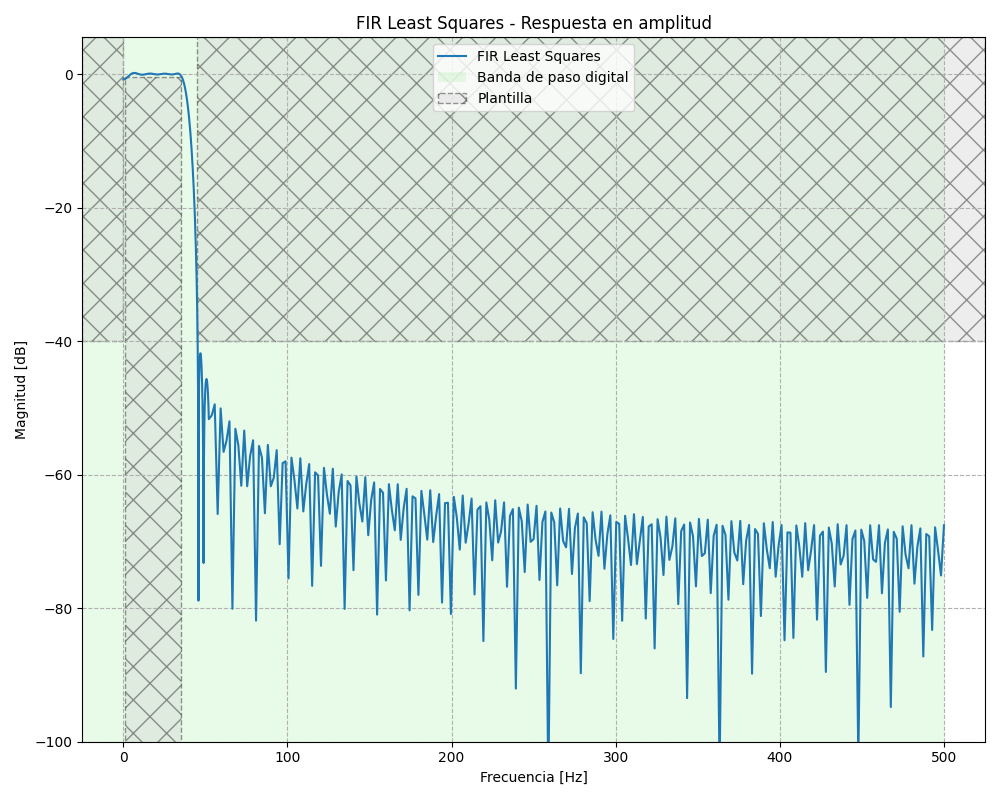

In [140]:
inc_f = 0.15
freqs = [0, 0.1 + .1, 0.5 - .2, 35 + .15, 45 - .15, 500]
# gain = [0, 40, 0.5, 0.5, 40, 0]
gain = [0, 0, 1, 1, 0, 0]
Ntaps_ls = 201
fs = 1000 # Hz
N = 10000
ww = np.concatenate( [ np.logspace(start = -2, stop = np.log10(2), num = 250 ),
                       np.linspace(start = 2.1, stop = 34, num = 250 ),
                       np.logspace(start = np.log10(34.1), stop = np.log10(52), num = 250 ),
                       np.linspace(start = 52.1, stop = fs/2, num = 250 )] )

num_ls_methd = sig.firls(Ntaps_ls, freqs, gain, fs=fs)
# Pasar a antisimétrico a mano, para que aparezca el 0 de transmisión en la frecuencia 0.0 Hz. Esto es porque firls no tiene la opción antisymmetric=True.
def to_typeIII(h):
    if len(h) % 2 == 0:
        raise ValueError("Tipo III requiere longitud impar")
    mid = len(h)//2
    h = np.concatenate((h[:mid+1], -h[mid+1:])) 
    h[mid] = 0.0
    return h

#num_ls_methd = to_typeIII(num_ls_methd)
f, h_ls = sig.freqz(b=num_ls_methd, a=[1], worN=ww, fs=fs)

plt.clf()
ax = plot_filt_mag(f, h_ls, 'FIR Least Squares', ax=None, label='FIR Least Squares')
plt.legend()

fpass = (1.0, 35.0)
fstop = (0.1, 45.0)
att_pass = 0.5
att_stop = 40
plot_plantilla(filter_type='bandpass', fpass=fpass, ripple=att_pass, fstop=fstop, attenuation=att_stop, fs=fs)

plt.legend()
plt.tight_layout()
plt.show()


## Remez Method

Para el método de remez, que se basa en la minimización de los picos en la oscilación de H(f) se logra una señal equiripple siempre que se llegue a converger la ecuación. Esto se debe a que remez es un método iterativo y no siempre funciona.

Para lograr que funcione la plantilla, se van ajustando los pesos y se aumenta la ganancia para usarla como offset. Además, se ajustan las freqs para que sean más limitantes de lo que en realidad son. Esto mejora el resultado al calcular para una condición mayor a la que se desea. Se utilizan taps impares para usar un filtro tipo 3 o 4.

Este método es el más optimo con respecto a los otros métodos. Es por eso que se puede lograr, teóricamente, el menor número de taps. Eso, sin embargo, es bastante complicado en este caso ya que requerimos una caida abismal entre .1 y .5

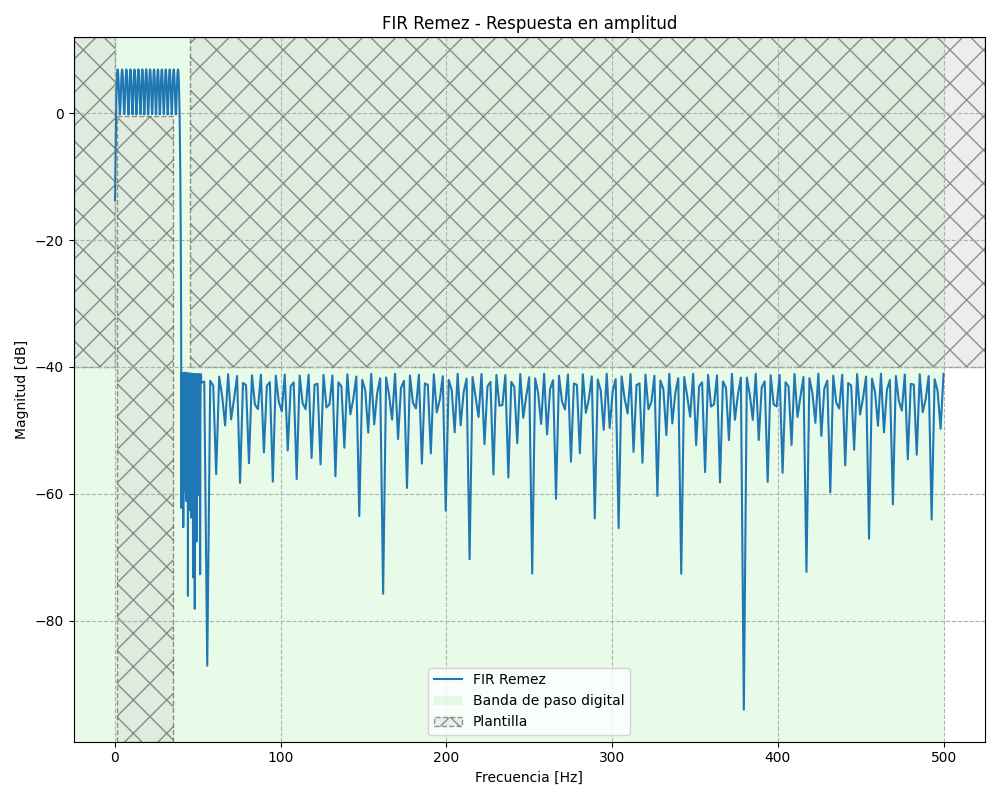

In [141]:
freqs = [0, 0.1 , 0.7, 35 + 4, 45 - 5, 500]
# gain = [0, 40, 0.5, 0.5, 40, 0]
gain = [0, 1.6, 0]
weight = [3, 1, 70]

Ntaps_remez = 901
fs = 1000 # Hz
N = 400
ww = np.concatenate( [ np.logspace(start = -2, stop = np.log10(2), num = 250 ),
                       np.linspace(start = 2.1, stop = 34, num = 250 ),
                       np.logspace(start = np.log10(34.1), stop = np.log10(52), num = 250 ),
                       np.linspace(start = 52.1, stop = fs/2, num = 250 )] )

num_remez_methd = sig.remez(Ntaps_remez, freqs, gain, weight=weight, fs=fs, type='bandpass', maxiter=30)
f, h_remez = sig.freqz(b=num_remez_methd, a=[1], worN=ww, fs=fs)

ax = plot_filt_mag(f, h_remez, 'FIR Remez', ax=None, label='FIR Remez')
plt.legend()

fpass = (1.0, 35.0)
fstop = (0.1, 45.0)
att_pass = 0.5
att_stop = 40
plot_plantilla(filter_type='bandpass', fpass=fpass, ripple=att_pass, fstop=fstop, attenuation=att_stop, fs=fs)

plt.legend()
plt.tight_layout()
plt.show()


## Comparación de métodos

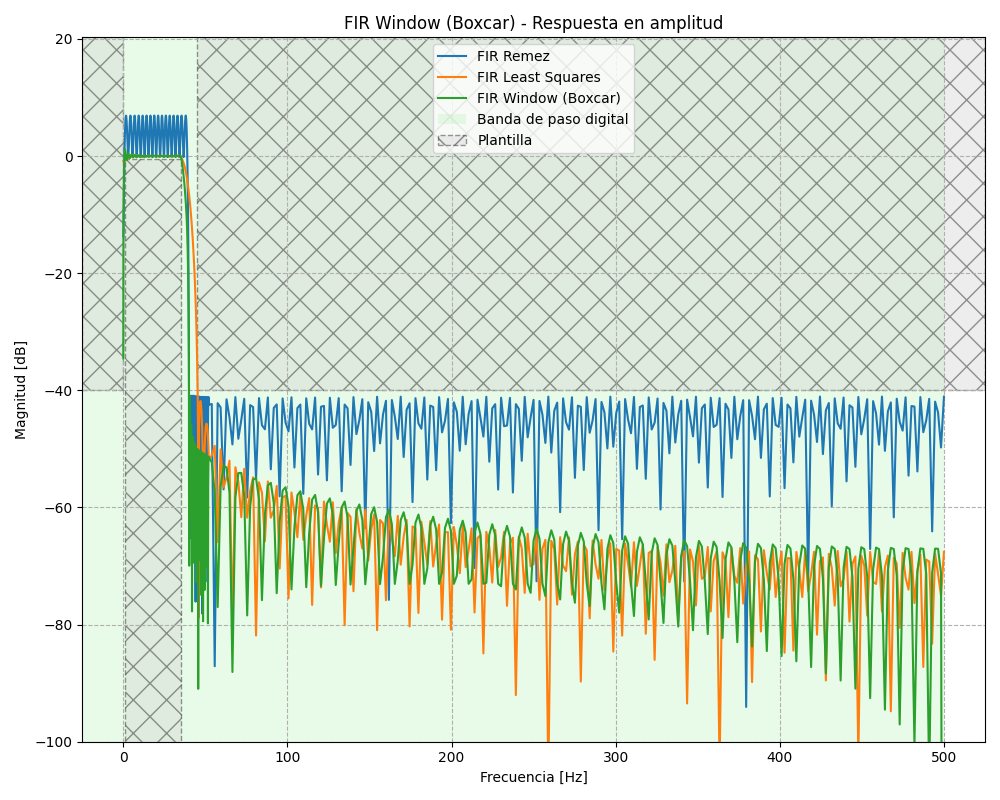

In [142]:
plt.clf()
ax = plot_filt_mag(f, h_remez, 'FIR Remez', ax=None, label='FIR Remez')
ax = plot_filt_mag(f, h_ls, 'FIR Least Squares', ax=ax, label='FIR Least Squares')
ax = plot_filt_mag(f, h_win, 'FIR Window (Boxcar)', ax=ax, label='FIR Window (Boxcar)')
plt.legend()

fpass = (1.0, 35.0)
fstop = (0.1, 45.0)
att_pass = 0.5
att_stop = 40
plot_plantilla(filter_type='bandpass', fpass=fpass, ripple=att_pass, fstop=fstop, attenuation=att_stop, fs=fs)

plt.legend()
plt.tight_layout()
plt.show()


# Filtrado de la señal

Se verifica el filtrado utilizando las señales fir. Algo importante es que el método de ventana, posee un desfazaje de 90°. Esto es similar a una transformada de Hilbert donde se pasa de real a imaginario. Esto rompe bastante el delay, por lo que solo esta transferencia se utilizará con filtfilt (el filtrado doble) que elimina los cambios de fase. Esto no es ideal ya que requiere una implementación a tiempos concretos y no se puede filtrar en tiempo real.

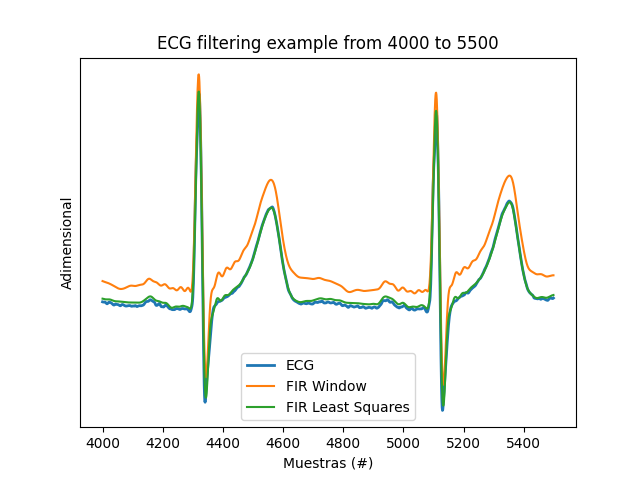

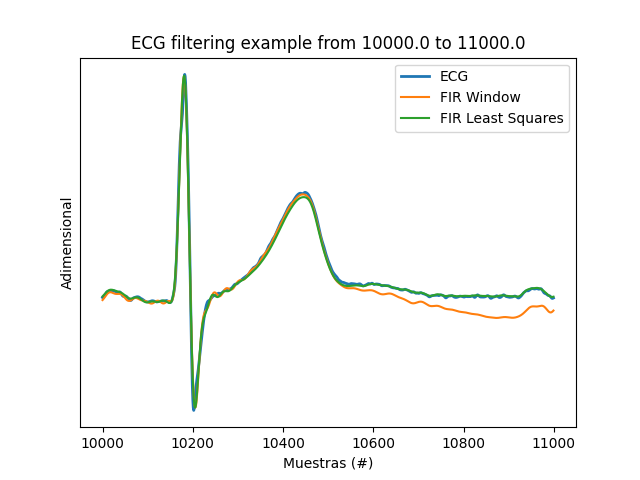

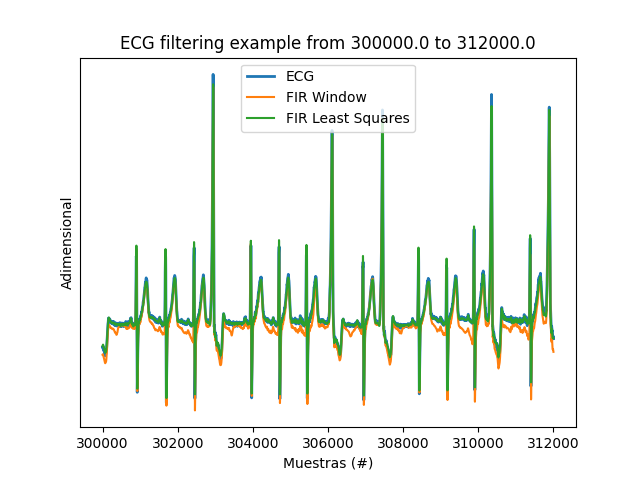

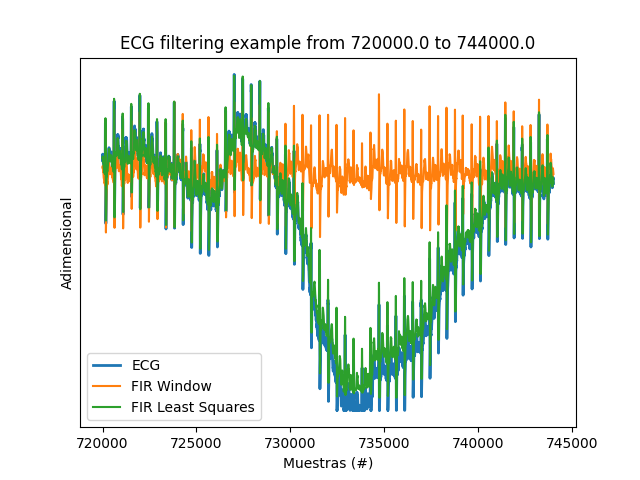

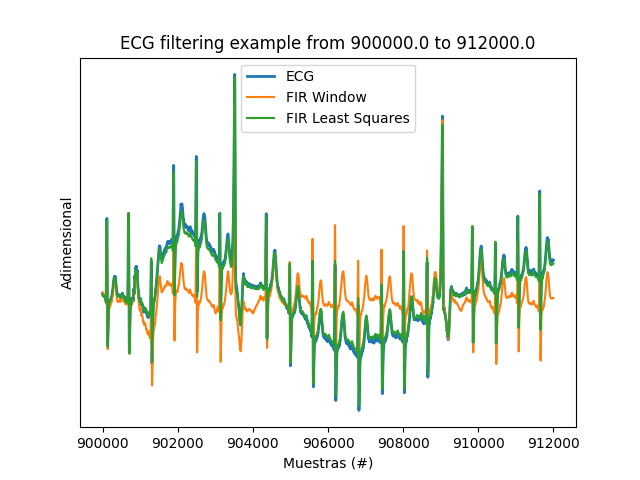

In [143]:
ECG_f_win = sig.filtfilt(b=num_win_methd, a=[1], x=ecg_one_lead)
delay_win = (Ntaps_win-1)//2

ECG_f_ls = sig.lfilter(b=num_ls_methd, a=[1], x=ecg_one_lead)
delay_ls = (Ntaps_ls-1)//2

ECG_f_remez = sig.lfilter(b=num_remez_methd, a=[1], x=ecg_one_lead)
delay_remez = (Ntaps_remez-1)//2

#%% Regiones de interés con ruido 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_win[zoom_region], label='FIR Window')
    plt.plot(zoom_region, ECG_f_ls[zoom_region + delay_ls], label='FIR Least Squares')
    #plt.plot(zoom_region, ECG_f_remez[zoom_region], label='FIR Remez')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
#%% Regiones de interés sin ruido 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_win[zoom_region], label='FIR Window')
    plt.plot(zoom_region, ECG_f_ls[zoom_region + delay_ls], label='FIR Least Squares')
    #plt.plot(zoom_region, ECG_f_remez[zoom_region- delay_remez], label='Cheby1')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

# MÉTODO EFICIENTE COMPUTACIONALMENTE

Los métodos anteriores obtienen coeficientes de una transformada y son aplicados directamente como la ecuación en diferencia del filtro. Esto está bien pero, en un ámbito computacional digital, existen métodos más directos para implementar lo mismo. Estos métodos a veces utilizan truquitos matemáticos para ahorrar cuentas. A continuación se implementará uno visto en clase.

Un promedio, se puede ver como obtener el valor medio -> integrar -> $\frac{1}{Z}$ -> pasabajos. 
Si nuestro filtro promedia N muestras, podría verse como una cajita en la que entran N pelotas y solo hay que sumar sus valores. 
Teniendo ya la cuenta inicial, en vez de recalcular todo simplemente se podría sumar el valor de la pelotita que entra y eliminar el valor de la última en la fila. De forma que:
$$
y[n] = y[n-1] + x[n] - x[n - N]
$$

Con 2 sumas se logra un promedio de N valores, siendo N-1 el orden de la ecuación de diferencia en Z:

$$
y = x + x z^1 + x z^2 + ... +x z^{N-1}
$$

Luego, se puede definir un filtro tal que, sumado con este pasabajos, entregue un pasatodo. Ese filtro DEBE ser pasa altos. Se puede demostrar que dicho filtro sigue la siguiente expresión:

$$
H_{hp} = H_{lp} - x\cdot z^{-M}
$$
En palabras, como el filtro genera delay (debido a las N sumas que debe realizar para calcular su primer número), se le debe restar la señal de entrada con el mismo delay para generar un verdadero pasa altos.
Este pasa altos presenta un cero de transmisión en continua perfecto y se puede interpretar como el cálculo del valor de continua y la sustracción de dicho valor.

**¿Cómo se implementa dicho filtro?**

Se implementa como:
$$
y[n] = y[n-1] + x[n] - x[n - N]
$$

Y su transferencia en Z se define como:
$$
H = \frac{1}{N}\frac{1-Z^{-N}}{1-Z^-1}
$$


**INTERPOLACIÓN**

Otra técnica, computacionalmente barata, es añadir ceros entre muestras (interpolar) o eliminar muestras (decimar). Estos procesos generan la compresión y expanción del espectro. Transforman nuestra señal de una fs real a una "fs ficticia" dando el mismo espectro pero agrandado o achicado.
En este caso se utilizará la interpolación. Interpolar encoge el espectro de la señal, provocando que las replicas de esta pasen por debajo de la fs de Nyquist. En nuestro filtro pasabajos esto es deseable, ya que podemos utilizar las réplicas del cero de transmisión en continua (que se encuentran en fs, 2fs, 3fs, ...) y colocarlas donde querramos tener un cero. Este filtro presenta la forma de un "peine" ya que es un pasa todo con multiples frecuencias donde vale 0. 


**¿Cómo se implementa la interpolación?**

En el dominio Z se define como la siguiente transformación

$$
Z \rightarrow Z^L \qquad L: cant Ceros - 1 
$$

**Función Pasa Altos:**
$$
T_H(Z)=Z^{-M}-T_R(Z)=Z^{-\frac{N-1}{2}}-\frac{1}{N}\frac{1-Z^{-N}}{1-Z^{-1}}
$$

**Función Pasa Altos con C filtros en cascada:**
$$
T_H(Z)=Z^{-M C}-T^C_R(Z)=Z^{-\frac{(N-1)C}{2}}-\left(\frac{1}{N}\frac{1-Z^{-N}}{1-Z^{-1}}\right)^C
$$

**Función Pasa Altos con C filtros en cascada e interpolación:**
$$
T_H(Z)=Z^{-L M C}-T^{C L}_R(Z)=Z^{-\frac{(N-1)C L}{2}}-\left(\frac{1}{N}\frac{1-Z^{-N L}}{1-Z^{-L}}\right)^C
$$

**Implementación:**

* Se implementa un algoritmo sencillo de promediado con interpolado L ya incluido. 
* Se pasa la señal por dicha función C veces.
* Se agarra la señal original, desplazada por un delay y se le resta la función filtrada C veces.



In [144]:
import numpy as np
import numpy.typing as npt

def complementary_delay_filter(x : npt.NDArray[np.number], 
                               x_filtered : npt.NDArray[np.number], 
                               delay: int
                               ) -> npt.NDArray[np.number]:
    """
    Calcula el complemento:
        y = z^(-delay) - H(z)
    x: señal de entrada
    x_filtered: señal filtrada
    delay: retraso del filtro
    """
    hp = np.zeros_like(x_filtered)
    hp[delay:] = x[:-delay] - x_filtered[delay:]

    return hp


def moving_average_recursive(x : npt.NDArray[np.number] , 
                             N : int, 
                             L : int = 1 
                             ) -> npt.NDArray[np.number]:
    y = np.zeros_like(x)

    for n in range(len(x)):
        x_n_N = x[n-N*L] if n >= N*L else 0.0
        y_old = y[n-L] if n >= L else 0.0

        y[n] = y_old + (x[n] - x_n_N)/N             # Funcion de diferencia recursiva para promedio movil
    return y

def delay_signal(x : npt.NDArray[np.number], 
                 delay: int
                 ) -> npt.NDArray[np.number]:
    '''
    Añade un retraso a la señal x. Se implementa como un desplazamiento de la señal hacia adelante, rellenando con ceros al inicio.
    '''
    y = np.zeros_like(x)
    y[delay:] = x[:-delay]
    return y

def lyons_lowpass(x : npt.NDArray[np.number], N : int, C : int = 2, L : int = 1) -> npt.NDArray[np.number]:
    """
    Filtro pasabajos recursivo de Lyons.

    H(z)=(z^(-M)*(1/N)*(1-z^-N)/(1-z^-1))^C

    N debe ser impar
    C debe ser par
    """
    if L == 0:
        raise ValueError("L debe ser mayor que 0.")
    
    # Check imputs
    x = np.asarray(x, dtype=float)

    # Apply the recursive moving average filter C times. 
    tr = x.copy()
    for _ in range(C):
        tr = moving_average_recursive(tr, N, L)

    return tr

def lyons_highpass(x : npt.NDArray[np.number], N : int, C : int = 2, L : int = 1) -> npt.NDArray[np.number]:
    """
    Filtro pasaaltos recursivo de Lyons.

    H(z)=z^(-MC) - (z^(-M)*(1/N)*(1-z^-N)/(1-z^-1))^C

    N debe ser impar
    C debe ser par
    """
    if L == 0:
        raise ValueError("L debe ser mayor que 0.")
    # Check imputs
    x = np.asarray(x, dtype=float)

    # delay value
    delay =  C*L*(N-1)/2
    if delay != int(delay) :
        raise ValueError("El delay M debe ser un entero. Asegúrese de que N sea par y C sea par.")
    delay = int(delay)

    # Apply the recursive moving average filter C times. 
    tr = x.copy()
    for _ in range(C):
        tr = moving_average_recursive(tr, N, L)

    # Delayed input signal
    xd = delay_signal(x, delay)

    return xd - tr

def delay_lyons_filter(N : int, C : int = 2, L : int = 1) -> int:
    """
    Calcula el retraso de un filtro de Lyons.
    """
    if L == 0:
        raise ValueError("L debe ser mayor que 0.")

    delay =  C*L*(N-1)/2
    if delay != int(delay) :
        raise ValueError("El delay M debe ser un entero. Asegúrese de que N sea par y C sea par.")

    return int(delay)

def kroneker_delta(n : int) -> npt.NDArray[np.number]:
    """
    Función delta de Kronecker.
    """
    delta = np.zeros(n)
    delta[0] = 1

    return delta

2.706168622523819e-16


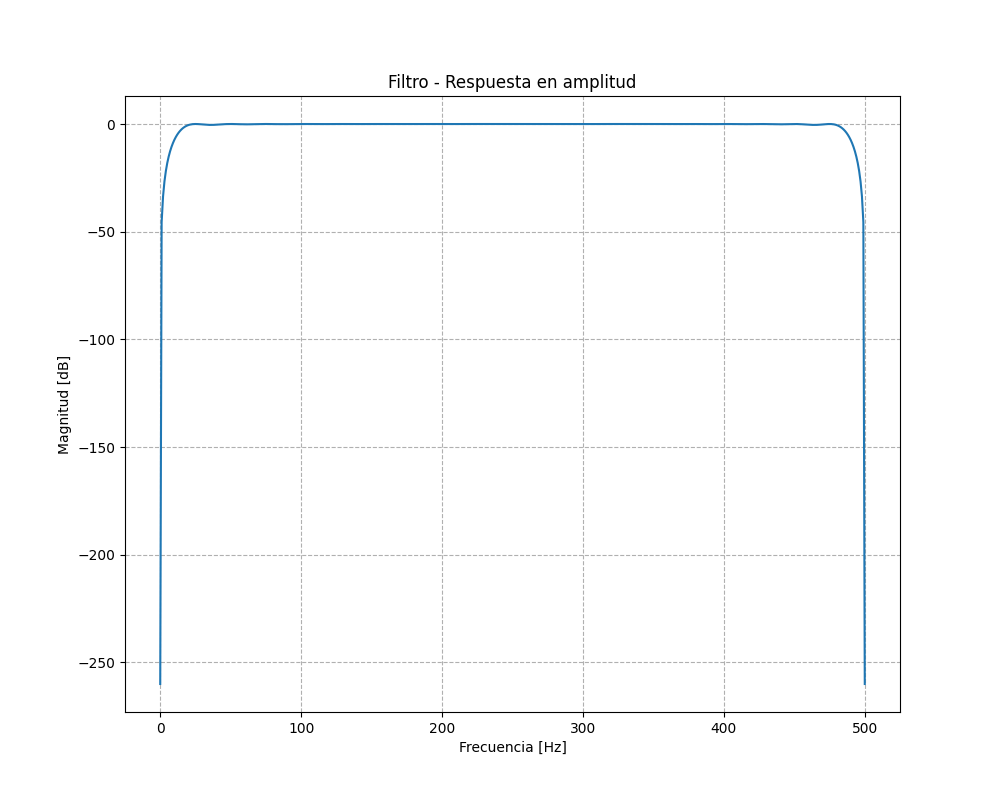

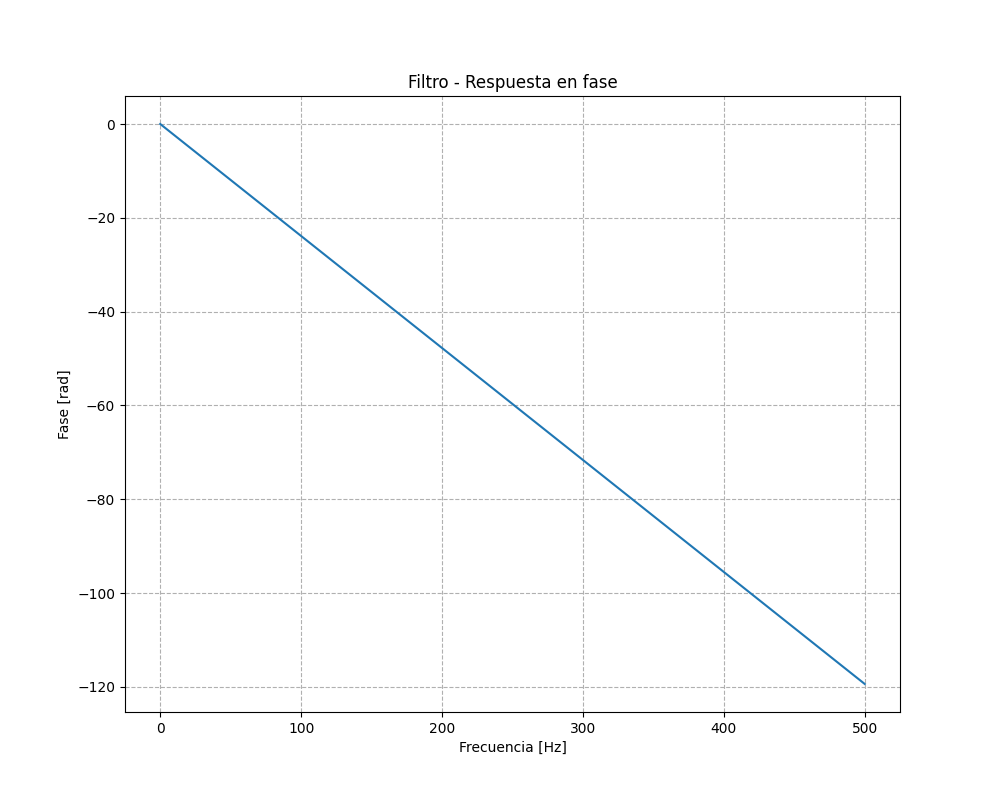

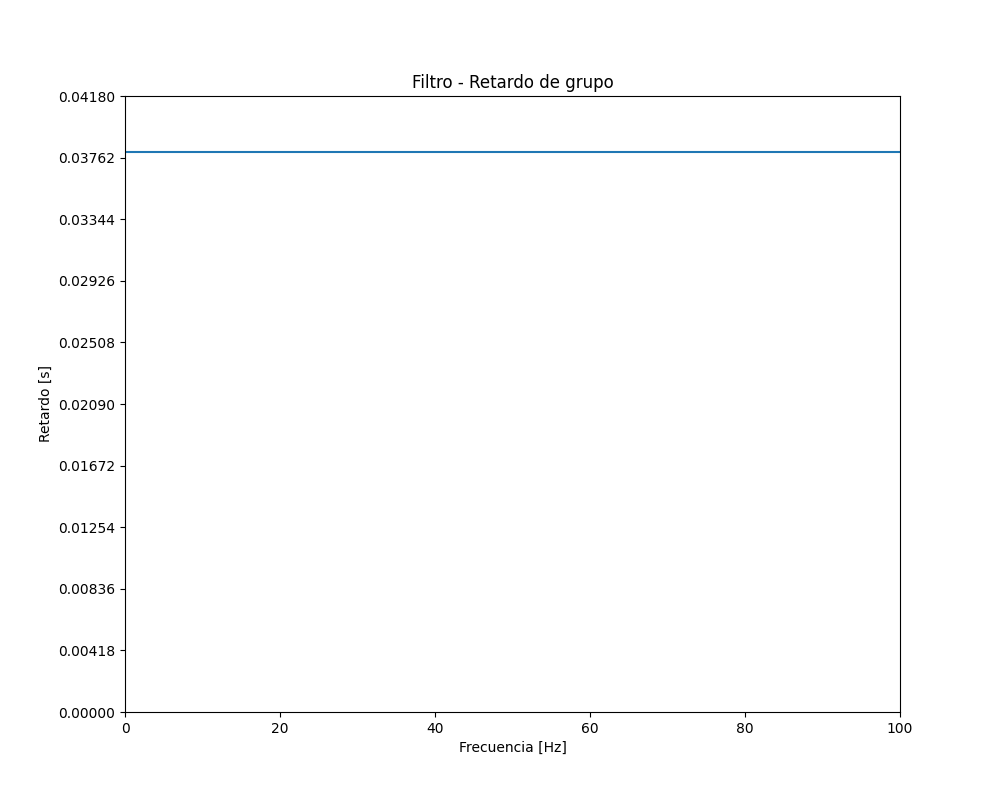

In [145]:
imp = kroneker_delta(1000)
fs = 1000

N = 20
C = 2
L = 2

h = lyons_highpass(imp, N, C=C, L=L)

delay = C*L*(N-1)/2
delay /= fs

H = np.fft.rfft(h)
f = np.fft.rfftfreq(len(h), 1/fs)

plot_filt_mag(f, H)
plot_filt_phase(f, H)
plot_filt_delay(f, H)
plt.ylim([0,delay*1.1])
plt.yticks(np.arange(0, delay*1.1, delay*.11))
plt.grid()
plt.xlim([0,100])
#plt.ylim([-80,5])
print(np.sum(h))

Se observa que se logró un filtro pasa altos, con un cero de transmisión en continua y un delay constante de 0.019 s (para L=1).

Ese delay corresponde a $D = C\frac{N-1}{2} = 19$. Con una fs de 1000 Hz, 19 muestras son 19ms 

Ahora sí, vamos a definir el filtro para nuestro caso puntual.

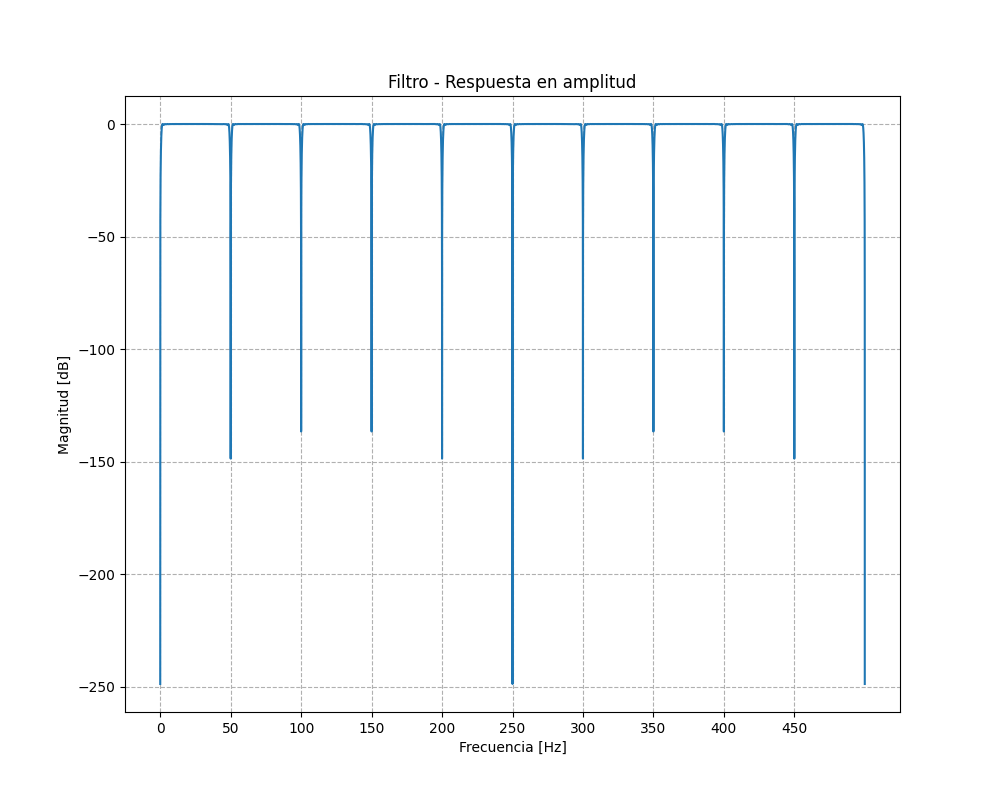

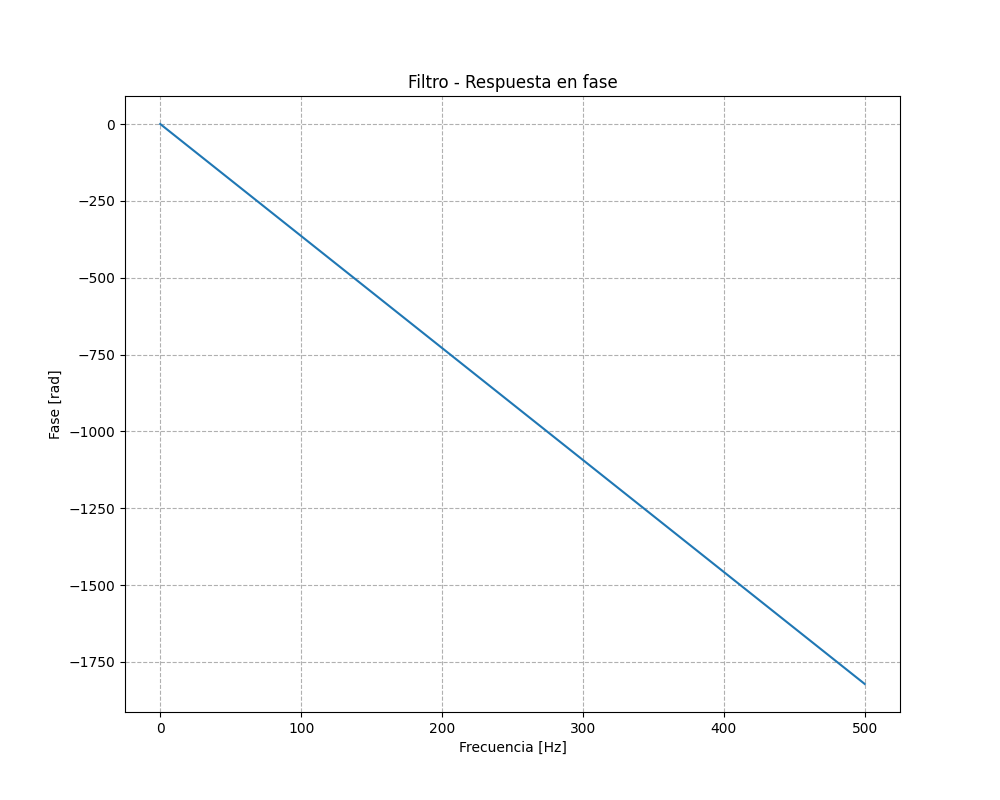

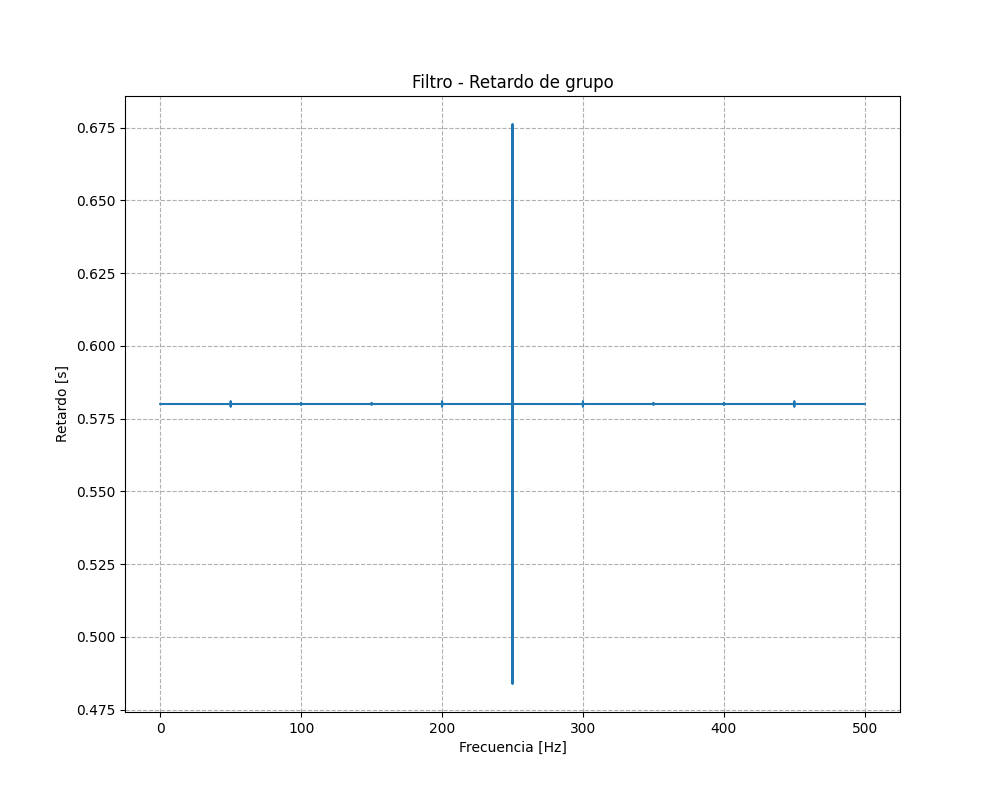

In [146]:
# Datos:
fs = 1000
f_cero = 50

# Valores del filtro:
N = 30
C = 2
L = fs//f_cero

# Respuesta al impulso:
delta = kroneker_delta(len(ecg_one_lead))
h_t = lyons_highpass(delta, N, C=C, L=L)

H = np.fft.rfft(h_t)
f = np.fft.rfftfreq(len(h_t), 1/fs)

plot_filt_mag(f, H)
plt.xticks(np.arange(0, fs/2, f_cero))
plot_filt_phase(f, H)
plot_filt_delay(f, H);


Plantilla casi perfecta del filtro (comparada con métodos anteriores)

In [147]:
ECG_f_recursive_lyons = lyons_highpass(ecg_one_lead, N=N, C=C, L=L)
delay_ECG_lyons = delay_lyons_filter(N=N, C=C, L=L)

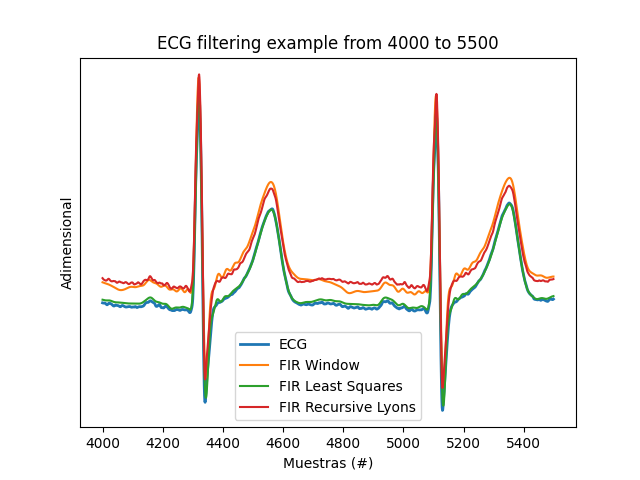

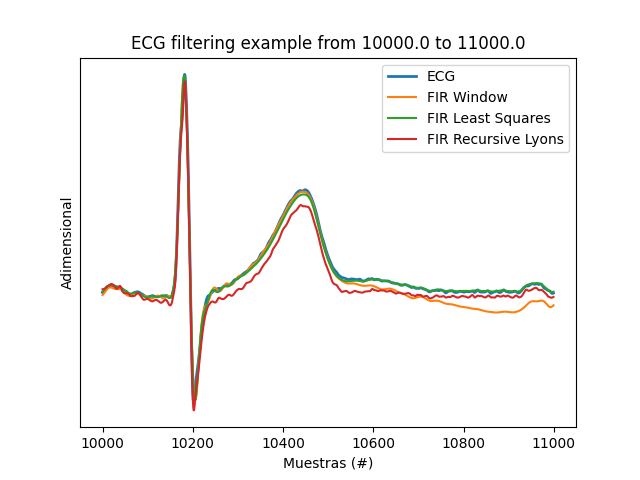

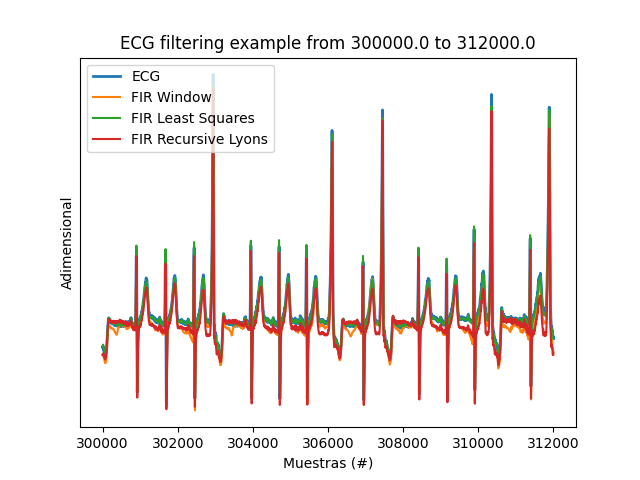

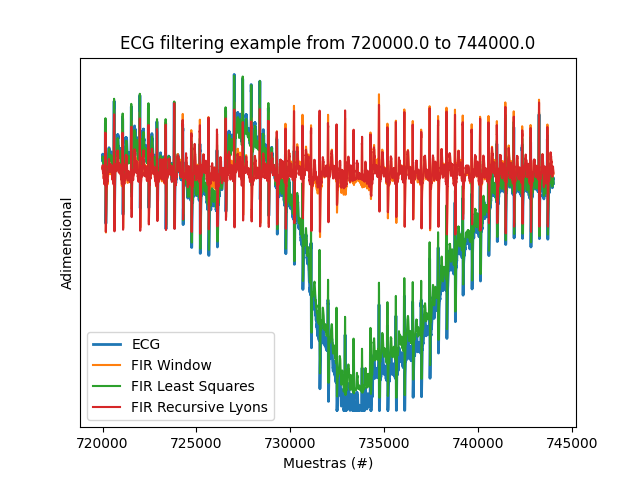

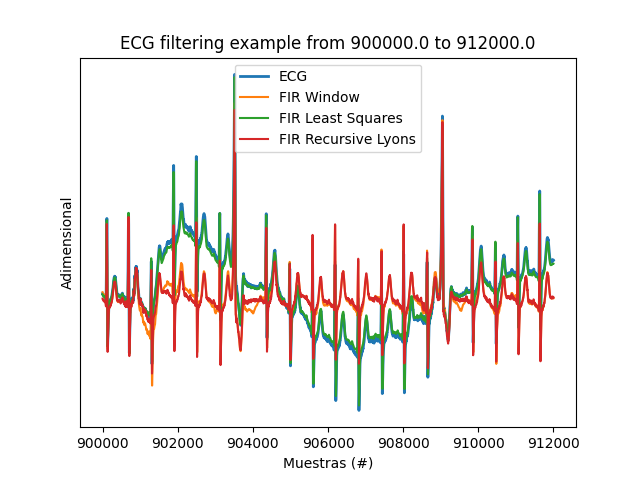

In [148]:
ECG_f_win = sig.filtfilt(b=num_win_methd, a=[1], x=ecg_one_lead)
delay_win = (Ntaps_win-1)//2

ECG_f_ls = sig.lfilter(b=num_ls_methd, a=[1], x=ecg_one_lead)
delay_ls = (Ntaps_ls-1)//2

ECG_f_recursive_lyons = ECG_f_recursive_lyons
delay_ECG_lyons = delay_ECG_lyons

#%% Regiones de interés con ruido 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_win[zoom_region], label='FIR Window')
    plt.plot(zoom_region, ECG_f_ls[zoom_region + delay_ls], label='FIR Least Squares')
    plt.plot(zoom_region, ECG_f_recursive_lyons[zoom_region + delay_ECG_lyons], label='FIR Recursive Lyons')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
#%% Regiones de interés sin ruido 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_win[zoom_region], label='FIR Window')
    plt.plot(zoom_region, ECG_f_ls[zoom_region + delay_ls], label='FIR Least Squares')
    plt.plot(zoom_region, ECG_f_recursive_lyons[zoom_region + delay_ECG_lyons], label='FIR Recursive Lyons')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()